# Stress-testing my own findings

Notebooks 01 to 03 report p-values from tests that assume independent
observations. Consecutive nights are not independent, so some of those
p-values are overstated. This notebook re-tests every headline claim with
methods that respect the structure of the data, and reports honestly which
claims hold, which weaken, and which do not survive.

**The rule that decides which correction applies:**

| Claim shape | Problem | Right tool |
|---|---|---|
| Two time periods (the 2024 dip) | Slow drift *is* the confound | effective n, block bootstrap |
| A trend over time (REM decline) | Persistent series wander without trending | block bootstrap on the slope |
| Days within a week (Sunday night) | Drift cancels; penalising it discards real signal | within-week permutation |
| Two slow series correlated | Shared drift inflates r | correlate within-week deviations |

Getting this backwards costs real findings in both directions. Applying the
autocorrelation penalty to the Sunday-night effect, which is a within-week
contrast, wrongly kills it. Not applying it to the REM trend wrongly keeps it.
Both cases appear below.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sqlalchemy import create_engine
from dotenv import load_dotenv

sys.path.insert(0, "..")  # repo root, so the analysis package resolves

from analysis.statistics import (
    bh_fdr, block_bootstrap_ci, cohens_d, effective_n, min_detectable_r,
    pearson_ci, weekly_contrast, welch_t_effective, within_week_deviations,
)

load_dotenv("../.env")

SURFACE, INK, INK2, BLUE = "#fcfcfb", "#0b0b0b", "#52514e", "#2a78d6"
RED, GREEN = "#c25a4a", "#5f8a4f"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

engine = create_engine(os.environ["DATABASE_URL"])
df = pd.read_sql("""
    SELECT day, sleep_score, readiness_score, activity_score, sleep_hours,
           avg_hrv, lowest_hr, temp_deviation, steps
    FROM staging.daily ORDER BY day
""", engine, parse_dates=["day"]).set_index("day")

sp = pd.read_sql("""
    SELECT day, rem_hours, sleep_hours, bedtime_start_local, bedtime_end_local, avg_hrv
    FROM staging.stg_sleep_periods
    WHERE type = 'long_sleep' AND sleep_hours > 3 ORDER BY day
""", engine, parse_dates=["day"]).set_index("day")
sp["rem_pct"] = sp.rem_hours / sp.sleep_hours * 100

stress = pd.read_sql("SELECT day, stress_high_hours FROM staging.stg_daily_stress",
                     engine, parse_dates=["day"]).set_index("day")
wk = pd.read_sql("SELECT day FROM staging.stg_workouts", engine, parse_dates=["day"])
d3 = sp.join(df[["temp_deviation"]]).join(stress)

inventory = []  # (label, p_naive, p_corrected, effect string)
print(f"{len(df)} days, {len(sp)} main sleep periods")

1244 days, 1257 main sleep periods


## 1. How much independent data is actually here?

The integrated autocorrelation time converts n nights into the number of
independent observations they carry. A ratio near 1.0 means the series behaves
like independent draws; a low ratio means most nights are near-copies of the
night before.

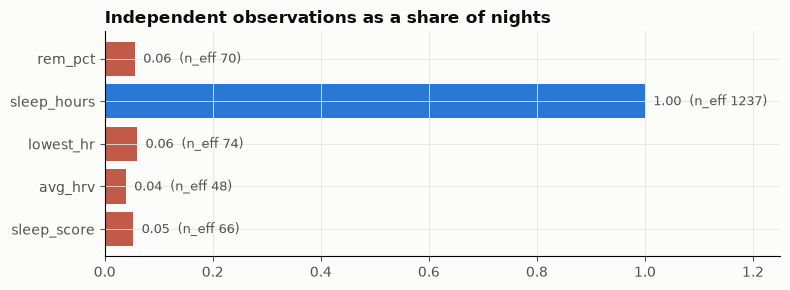

                n     n_eff  ratio
series                            
sleep_score  1244    65.775  0.053
avg_hrv      1237    48.339  0.039
lowest_hr    1237    74.274  0.060
sleep_hours  1237  1237.000  1.000
rem_pct      1257    70.119  0.056


In [2]:
series = {
    "sleep_score": df.sleep_score.dropna(),
    "avg_hrv": df.avg_hrv.dropna(),
    "lowest_hr": df.lowest_hr.dropna(),
    "sleep_hours": df.sleep_hours.dropna(),
    "rem_pct": sp.rem_pct.dropna(),
}
rows = [(k, len(v), effective_n(v), effective_n(v) / len(v)) for k, v in series.items()]
eff = pd.DataFrame(rows, columns=["series", "n", "n_eff", "ratio"]).set_index("series")

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(eff.index, eff.ratio, color=[RED if r < 0.3 else BLUE for r in eff.ratio])
for i, (r, ne) in enumerate(zip(eff.ratio, eff.n_eff)):
    ax.annotate(f"{r:.2f}  (n_eff {ne:.0f})", (r, i), xytext=(6, 0),
                textcoords="offset points", va="center", color=INK2, fontsize=9)
ax.set_xlim(0, 1.25)
ax.set_title("Independent observations as a share of nights",
             loc="left", fontweight="bold", color=INK)
plt.tight_layout(); plt.show()

print(eff.round(3).to_string())

**Physiology decides the ratio.** HRV carries about 48 independent
observations out of 1,237 nights: it is a slow signal that drifts over weeks,
so consecutive readings are nearly the same measurement. Sleep *duration*
sits at 1.00, because how long I sleep on Tuesday says almost nothing about
Wednesday.

The practical consequence: any claim resting on HRV or REM share over long
stretches has far less evidence behind it than the raw night count suggests.
Claims about duration do not have this problem.

## 2. Between-period claims: was the 2024 dip real?

Here the autocorrelation penalty is entirely fair. The claim compares two
contiguous five-month blocks, which is exactly the comparison slow drift can
fake. Reported three ways: the naive p-value, one rescaled to effective n, and
a block bootstrap that resamples 30-day blocks. Effect sizes throughout,
because Cohen's d does not shrink when the independence assumption is dropped.

In [3]:
dip = df.loc["2023-12-01":"2024-04-30"]
base = df.loc["2022-12-01":"2023-04-30"]

rows = []
for col in ["avg_hrv", "lowest_hr", "sleep_score", "sleep_hours"]:
    a, b = base[col].dropna(), dip[col].dropna()
    res = welch_t_effective(a, b)
    cd = cohens_d(a, b)
    lo, hi = block_bootstrap_ci(a, b, block=30, n_boot=4000)
    rows.append({
        "signal": col, "diff": res["diff"],
        "n_eff": f"{res['n_eff'][0]:.0f}/{res['n_eff'][1]:.0f}",
        "p_naive": res["p_naive"], "p_eff": res["p_eff"],
        "d": cd["d"], "d_ci": f"[{cd['ci'][0]:+.2f}, {cd['ci'][1]:+.2f}]",
        "block_ci": f"[{lo:+.2f}, {hi:+.2f}]",
    })
    inventory.append((f"dip: {col}", res["p_naive"], res["p_eff"], f"d={cd['d']:+.2f}"))

dip_tbl = pd.DataFrame(rows).set_index("signal")
print(dip_tbl.to_string(float_format=lambda v: f"{v:+.3g}"))

              diff    n_eff   p_naive     p_eff      d            d_ci         block_ci
signal                                                                                 
avg_hrv      +10.3    53/27 +9.23e-12 +0.000309 +0.871  [+0.62, +1.12]  [+4.70, +14.64]
lowest_hr    -4.55    67/35 +7.37e-15 +1.17e-05  -1.02  [-1.28, -0.77]   [-5.82, -2.84]
sleep_score  +9.36  138/128 +8.67e-11 +8.67e-11  +0.84  [+0.59, +1.09]  [+7.04, +12.50]
sleep_hours +0.455  138/127   +0.0591   +0.0591 +0.232  [-0.01, +0.47]   [+0.04, +0.86]


**Verdict: HOLDS, and comfortably.** HRV pays the biggest penalty, 138 nights
collapsing to 53 independent observations in the baseline window and 27 in the
dip window, which moves its p-value from 9e-12 to 3e-4. Night heart rate goes
from 7e-15 to 1e-5. Both stay significant, and the effect sizes are large:
d = 0.87 for HRV, d = 1.02 for night heart rate, d = 0.84 for sleep score.
Every block bootstrap interval excludes zero.

Sleep score is an interesting exception: inside these two five-month windows
it shows no positive autocorrelation at all, so its effective n equals its raw
n and its p-value does not move. Over the full four years sleep score does look
persistent (65 independent observations out of 1,244), which means that
persistence comes from slow multi-month drift rather than from one night
predicting the next. Within a single winter there is nothing for the penalty
to remove.

Sleep duration is the honest exception: d = 0.23 with an interval touching
zero. It moved, but it does not carry the dip, which is what notebook 01
already said.

One framing correction. Notebook 01 reports "rolling HRV sat below -1.5 sigma
for 44 consecutive days". That is one sustained event, not 44 independent
pieces of evidence, because consecutive days of a 30-day rolling mean are
nearly the same number by construction. The dip is well supported by the
winter-on-winter comparison above; the 44-day count describes its duration
and should not be read as its strength.

## 3. Within-week claims: the Sunday-night effect

This is where the naive correction misfires. Sunday nights sit seven days
apart, so seasonal drift moves the Sunday group and the comparison group
together and largely cancels from the difference. Penalising it by effective n
throws away a real effect.

The correct test never leaves the week: express every night as a deviation
from its own week's mean, then ask whether Sunday's deviation is unusual by
permuting which positions inside each week get picked. Complete weeks only, so
each week contributes the same shape.

In [4]:
score = df.sleep_score.dropna()

# The naive approach, for comparison: treat the two groups as autocorrelated samples
naive = welch_t_effective(score[score.index.dayofweek == 0],
                          score[score.index.dayofweek != 0])
sun = weekly_contrast(score, [0])
rem_we = weekly_contrast(sp.rem_pct.dropna(), [5, 6])

print("SUNDAY NIGHT (sleep score)")
print(f"  raw group means      : {score[score.index.dayofweek == 0].mean():.1f} "
      f"vs {score[score.index.dayofweek != 0].mean():.1f}")
print(f"  naive two-sample     : p={naive['p_naive']:.4f} -> effective-n p={naive['p_eff']:.4f}  <- over-penalised")
print(f"  within-week contrast : {sun['observed']:+.2f} points vs week average")
print(f"  permutation p        : {sun['p_perm']:.4f}  ({sun['n_weeks']} complete weeks)")
print(f"  week-level 95% CI    : [{sun['ci'][0]:+.2f}, {sun['ci'][1]:+.2f}] points")
print()
print("WEEKEND REM SHARE (notebook 03, H5)")
print(f"  within-week contrast : {rem_we['observed']:+.2f} pp vs week average")
print(f"  permutation p        : {rem_we['p_perm']:.4f}  ({rem_we['n_weeks']} complete weeks)")
print(f"  week-level 95% CI    : [{rem_we['ci'][0]:+.2f}, {rem_we['ci'][1]:+.2f}] pp")

inventory.append(("sunday night effect", naive["p_naive"], sun["p_perm"],
                  f"{sun['observed']:+.2f} pts"))
inventory.append(("H5 weekend REM share", 0.0110, rem_we["p_perm"],
                  f"{rem_we['observed']:+.2f} pp"))

SUNDAY NIGHT (sleep score)
  raw group means      : 68.6 vs 72.1
  naive two-sample     : p=0.0017 -> effective-n p=0.1188  <- over-penalised
  within-week contrast : -3.37 points vs week average
  permutation p        : 0.0007  (126 complete weeks)
  week-level 95% CI    : [-5.51, -1.30] points

WEEKEND REM SHARE (notebook 03, H5)
  within-week contrast : +0.37 pp vs week average
  permutation p        : 0.1495  (111 complete weeks)
  week-level 95% CI    : [-0.13, +0.87] pp


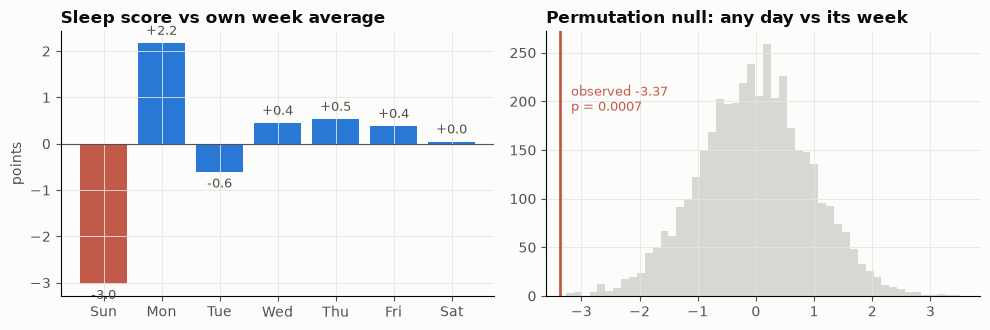

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))

dev = within_week_deviations(score)
by_dow = dev.groupby(dev.index.dayofweek).mean()
names = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
colors = [RED if d == by_dow.idxmin() else BLUE for d in by_dow.index]
axes[0].bar(names, by_dow.values, color=colors)
axes[0].axhline(0, color=INK2, linewidth=0.8)
axes[0].set_title("Sleep score vs own week average", loc="left",
                  fontweight="bold", color=INK)
axes[0].set_ylabel("points")
for i, v in enumerate(by_dow.values):
    axes[0].annotate(f"{v:+.1f}", (i, v), ha="center",
                     va="bottom" if v > 0 else "top",
                     xytext=(0, 4 if v > 0 else -4), textcoords="offset points",
                     color=INK2, fontsize=9)

# Permutation null vs observed
rng = np.random.default_rng(1)
weeks = [g.sort_index().values for _, g in score.groupby(score.index.to_period("W"))
         if len(g) == 7]
null = np.array([np.mean([b[rng.permutation(7)[:1]].mean() - b.mean() for b in weeks])
                 for _ in range(4000)])
axes[1].hist(null, bins=50, color="#d8d7d3")
axes[1].axvline(sun["observed"], color=RED, linewidth=2)
axes[1].annotate(f"observed {sun['observed']:+.2f}\np = {sun['p_perm']:.4f}",
                 (sun["observed"], axes[1].get_ylim()[1] * 0.7),
                 xytext=(8, 0), textcoords="offset points", color=RED, fontsize=9)
axes[1].set_title("Permutation null: any day vs its week", loc="left",
                  fontweight="bold", color=INK)
plt.tight_layout(); plt.show()

**Sunday night: HOLDS.** The two-sided permutation test puts it at p = 0.0007
with a week-level interval of [-5.5, -1.3] points. Notebook 01 published a
bootstrap interval of 1.4 to 5.7 points worse; the properly specified test
gives 1.3 to 5.5. The original conclusion was right and the original method
was loose.

Note what the naive correction did to it: p = 0.0017 became p = 0.12, which
would have retired a true finding. Choosing the correction to match the claim
shape matters as much as applying one.

**Weekend REM share (H5): DOWNGRADED to inconclusive.** Notebook 03 called
this "BACKWARDS" on the strength of p = 0.011 from a two-sample t-test. Once
the week structure is respected the effect is +0.37 points of REM share with an
interval of [-0.13, +0.87] and a two-sided permutation p of 0.15. The direction
still matches what H3 predicts, and that is all that can be claimed. The
verdict in notebook 03 has been amended.

## 4. Correlations: does the relationship survive drift removal?

Two slowly drifting series can correlate simply because both trend over four
years. Recomputing each correlation on within-week deviations removes anything
slower than a week and leaves only same-week covariation.

In [6]:
df["prev_steps"] = df.steps.shift(1)
df["prev_activity"] = df.activity_score.shift(1)
sp["wake_hour"] = sp.bedtime_end_local.dt.hour + sp.bedtime_end_local.dt.minute / 60

pairs = [
    (df, "sleep_hours", "sleep_score", "hours slept vs sleep score"),
    (df, "avg_hrv", "sleep_score", "night HRV vs sleep score"),
    (df, "prev_steps", "sleep_score", "prev-day steps vs sleep score"),
    (df, "prev_activity", "sleep_score", "prev-day activity vs sleep score"),
    (df, "sleep_score", "readiness_score", "sleep score vs readiness"),
    (sp, "sleep_hours", "rem_hours", "H3a duration vs REM hours"),
    (sp, "wake_hour", "rem_pct", "H3b wake time vs REM share"),
    (sp, "avg_hrv", "rem_pct", "H8 night HRV vs REM share"),
]

rows = []
for frame, x, y, label in pairs:
    sub = frame[[x, y]].dropna()
    r_raw, p_raw = stats.pearsonr(sub[x], sub[y])
    dx = within_week_deviations(sub[x])
    dy = within_week_deviations(sub[y])
    r_wk, p_wk = stats.pearsonr(dx, dy)
    lo, hi = pearson_ci(r_wk, len(sub))
    rows.append({"relationship": label, "n": len(sub), "r_raw": r_raw,
                 "p_raw": p_raw, "r_within_week": r_wk, "p_within_week": p_wk,
                 "ci": f"[{lo:+.2f}, {hi:+.2f}]"})
    inventory.append((label, p_raw, p_wk, f"r={r_wk:+.2f}"))

corr_tbl = pd.DataFrame(rows).set_index("relationship")
print(corr_tbl.to_string(float_format=lambda v: f"{v:.3g}"))

                                     n   r_raw     p_raw  r_within_week  p_within_week              ci
relationship                                                                                          
hours slept vs sleep score        1237    0.74 7.59e-215          0.772      3.32e-245  [+0.75, +0.79]
night HRV vs sleep score          1237   0.248  8.67e-19           0.22       5.79e-15  [+0.17, +0.27]
prev-day steps vs sleep score     1243  0.0466     0.101       -0.00116          0.968  [-0.06, +0.05]
prev-day activity vs sleep score  1239  0.0903   0.00146        0.00934          0.743  [-0.05, +0.06]
sleep score vs readiness          1244   0.667 4.24e-161          0.715      2.06e-195  [+0.69, +0.74]
H3a duration vs REM hours         1257   0.797 2.54e-277          0.821       6.4e-308  [+0.80, +0.84]
H3b wake time vs REM share        1257   0.209  6.52e-14          0.185        3.7e-11  [+0.13, +0.24]
H8 night HRV vs REM share         1257 -0.0465    0.0994        -0.0661  

**Verdict: the strong relationships get stronger.** Duration versus sleep
score rises from r = 0.74 to r = 0.77 once drift is removed, duration versus
REM hours from 0.80 to 0.82, and sleep score versus readiness from 0.67 to
0.72. That is the signature of a genuine same-day mechanism: stripping the
slow component removes noise rather than the effect.

HRV versus sleep score holds at r = 0.22 (p = 6e-15), and wake time versus REM
share holds at r = 0.19. Both survive; the earlier effective-n screen was too
blunt for them.

The previous-day activity claims collapse to nothing. Notebook 01 reported
r = 0.09 for previous-day activity; within week it is r = 0.01, p = 0.74. Its
takeaway already said this barely moves the score, and the honest number is
zero.

H8 changes direction of interpretation and needs stating carefully. Notebook 03
recorded it as a clean null (r = -0.05, p = 0.10). Within week it becomes
r = -0.066 at p = 0.019, which survives FDR adjustment below. So it is no
longer a null, but the effect explains 0.4% of the variance in REM share, and
its sign is the opposite of the hypothesis: higher HRV goes with slightly
*less* REM share. An effect that small and that backwards is not a mechanism to
act on. The honest description is "detectable, negligible, and probably not
what the hypothesis meant", not "no effect" and not "confirmed".

## 5. The REM decline: a trend, or a step?

Notebook 03 reported the REM share falling 1.1 percentage points per year at
p = 3e-8, fitted by OLS on 48 monthly means. Monthly means of a persistent
series are themselves persistent, and a wandering series produces impressive
looking trends with no trend behind them. The honest test resamples six-month
blocks and asks how often the fitted slope even keeps its sign.

In [7]:
monthly = sp.rem_pct.resample("ME").mean().dropna()
slope, intercept, r_v, p_v, se = stats.linregress(np.arange(len(monthly)), monthly.values)

rng = np.random.default_rng(3)
def bootstrap_slopes(series, block=6, n_boot=5000):
    v, n = series.values, len(series)
    n_blocks = int(np.ceil(n / block))
    out = np.empty(n_boot)
    for i in range(n_boot):
        starts = rng.integers(0, n - block + 1, n_blocks)
        resampled = np.concatenate([v[s:s + block] for s in starts])[:n]
        out[i] = stats.linregress(np.arange(n), resampled)[0] * 12
    return out

slopes = bootstrap_slopes(monthly)
lo, hi = np.percentile(slopes, [2.5, 97.5])

CHANGE = pd.Timestamp("2023-11-30")
pre = sp.loc[:"2023-10-31", "rem_pct"]
post = sp.loc["2024-01-01":, "rem_pct"]
cd_step = cohens_d(pre, post)
post_monthly = sp.loc["2024-01-01":, "rem_pct"].resample("ME").mean().dropna()
s_post, _, _, p_post, _ = stats.linregress(np.arange(len(post_monthly)), post_monthly.values)

print(f"OLS slope            : {slope*12:+.2f} pp/year, p={p_v:.1e}")
print(f"block bootstrap 95%  : [{lo:+.2f}, {hi:+.2f}] pp/year")
print(f"slopes below zero    : {(slopes < 0).mean():.1%}  <- a coin flip")
print()
print(f"step at the algorithm change: {pre.mean():.1f}% -> {post.mean():.1f}%  "
      f"(d={cd_step['d']:+.2f} [{cd_step['ci'][0]:+.2f}, {cd_step['ci'][1]:+.2f}])")
print(f"trend after the change only : {s_post*12:+.2f} pp/year, p={p_post:.3f}")

inventory.append(("H2 REM decline as a trend", p_v, (slopes >= 0).mean() * 2, f"{slope*12:+.2f} pp/yr"))

OLS slope            : -1.11 pp/year, p=3.4e-08
block bootstrap 95%  : [-0.87, +0.84] pp/year
slopes below zero    : 52.1%  <- a coin flip

step at the algorithm change: 20.1% -> 17.2%  (d=+0.62 [+0.49, +0.74])
trend after the change only : -0.45 pp/year, p=0.102


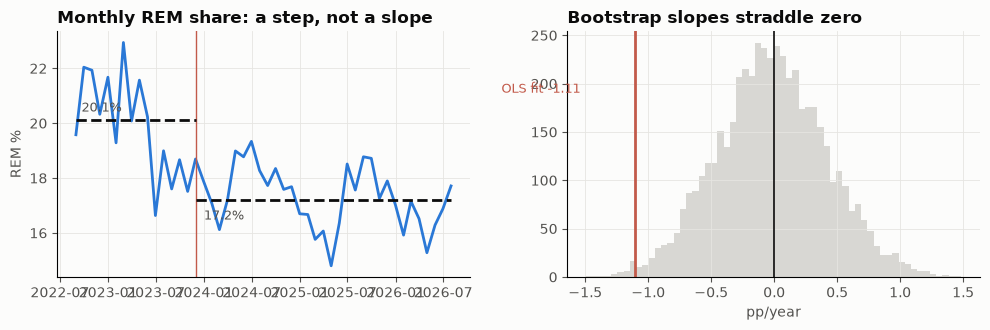

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))

axes[0].plot(monthly.index, monthly.values, color=BLUE, linewidth=2)
axes[0].axvline(CHANGE, color=RED, linewidth=1)
axes[0].hlines(pre.mean(), monthly.index.min(), CHANGE, color=INK, linewidth=2, linestyle="--")
axes[0].hlines(post.mean(), CHANGE, monthly.index.max(), color=INK, linewidth=2, linestyle="--")
axes[0].annotate(f"{pre.mean():.1f}%", (monthly.index.min(), pre.mean()),
                 xytext=(4, 6), textcoords="offset points", color=INK2, fontsize=9)
axes[0].annotate(f"{post.mean():.1f}%", (CHANGE, post.mean()),
                 xytext=(6, -14), textcoords="offset points", color=INK2, fontsize=9)
axes[0].set_title("Monthly REM share: a step, not a slope", loc="left",
                  fontweight="bold", color=INK)
axes[0].set_ylabel("REM %")

axes[1].hist(slopes, bins=60, color="#d8d7d3")
axes[1].axvline(0, color=INK, linewidth=1.2)
axes[1].axvline(slope * 12, color=RED, linewidth=2)
axes[1].annotate(f"OLS fit {slope*12:+.2f}", (slope * 12, axes[1].get_ylim()[1] * 0.75),
                 xytext=(-96, 0), textcoords="offset points", color=RED, fontsize=9)
axes[1].set_title("Bootstrap slopes straddle zero", loc="left",
                  fontweight="bold", color=INK)
axes[1].set_xlabel("pp/year")
plt.tight_layout(); plt.show()

**Verdict: NOT DEMONSTRATED as a trend.** The block bootstrap interval runs
from -0.9 to +0.8 percentage points per year and 52% of resampled slopes fall
below zero. The p = 3e-8 came from treating 48 correlated monthly means as
independent; there is no reliable linear decline to report.

What the data does support is a **level shift**, from 20.1% before November
2023 to 17.2% after January 2024, d = 0.62. That shift lands on the Oura
staging algorithm update, which is the explanation notebook 03 raised as a
caveat and which now becomes the leading one. Within the post-update period
the slope is -0.45 pp/year at p = 0.10, so there is no established decline on
either side of the step.

Notebook 03's H2 verdict moves from "PARTLY TRUE" to "measurement artefact is
the better explanation". This is the one place where a published number does
not survive, and the README has been corrected.

## 6. Multiple comparisons

Notebooks 01 and 03 test the same dataset many times over. The fifteen
headline claims are collected below; at alpha = 0.05 that is roughly one false
positive expected by chance. Benjamini-Hochberg is the right adjustment here
rather than Bonferroni: the tests share a dataset and are heavily dependent, so
controlling the false discovery rate is appropriate while Bonferroni would be
needlessly conservative.

Both columns are shown, adjusted on the original p-values and on the
methodologically corrected ones, so the two problems can be told apart.

In [9]:
labels = [x[0] for x in inventory]
p_naive = np.array([x[1] for x in inventory])
p_corr = np.array([np.clip(x[2], 1e-300, 1.0) for x in inventory])
effects = [x[3] for x in inventory]

adj_naive = bh_fdr(p_naive)
adj_corr = bh_fdr(p_corr)

out = pd.DataFrame({
    "effect": effects,
    "p_original": p_naive,
    "BH_original": adj_naive,
    "p_corrected": p_corr,
    "BH_corrected": adj_corr,
    "verdict": ["holds" if a < 0.05 else ("marginal" if a < 0.10 else "not significant")
                for a in adj_corr],
}, index=labels)

print(f"{len(out)} tests in the inventory")
print(out.to_string(float_format=lambda v: f"{v:.2e}" if v < 1e-3 else f"{v:.4f}"))

15 tests in the inventory
                                       effect  p_original  BH_original  p_corrected  BH_corrected          verdict
dip: avg_hrv                          d=+0.87    9.23e-12     1.98e-11     3.09e-04      5.80e-04            holds
dip: lowest_hr                        d=-1.02    7.37e-15     2.21e-14     1.17e-05      2.52e-05            holds
dip: sleep_score                      d=+0.84    8.67e-11     1.63e-10     8.67e-11      2.17e-10            holds
dip: sleep_hours                      d=+0.23      0.0591       0.0682       0.0591        0.0806         marginal
sunday night effect                 -3.37 pts      0.0017       0.0023     7.50e-04        0.0012            holds
H5 weekend REM share                 +0.37 pp      0.0110       0.0137       0.1495        0.1869  not significant
hours slept vs sleep score            r=+0.77   7.59e-215    5.69e-214    3.32e-245     2.49e-244            holds
night HRV vs sleep score              r=+0.22    8.67e

**Verdict: multiple comparisons change nothing on their own.** Compare
`p_original` with `BH_original`: no claim's verdict flips from the adjustment
alone. Every surviving claim sits far below 0.05 and the failures were already
failing.

All the movement comes from the methodological corrections instead. H2 goes
from 3e-8 to not significant once the slope is bootstrapped, H5 from 0.011 to
0.15 once the week structure is respected, and H8 travels the other way, from
0.10 to 0.019, once slow drift is removed. Three verdicts changed and none of
them changed because of Benjamini-Hochberg.

Worth stating plainly, since it was my first suspicion and it was wrong: the
autocorrelation of daily data did far more damage here than testing fifteen
hypotheses did.

## 7. Power: what the null results can actually rule out

Notebook 03's value is mostly in what it failed to find. A null result is only
worth something with a stated minimum detectable effect, otherwise "no effect"
means "absence of evidence" rather than "evidence of absence".

In [10]:
nulls = [
    ("H6 stress hours vs REM share", d3[["stress_high_hours", "rem_pct"]].dropna().shape[0]),
    ("H7 workout day vs rest day", len(sp)),
    ("H8 night HRV vs REM share", sp[["avg_hrv", "rem_pct"]].dropna().shape[0]),
    ("H9 fever nights vs well nights", int((d3.temp_deviation > 0.5).sum())),
]

rows = [{"null result": label, "n": n,
         "detectable r (80% power)": min_detectable_r(n),
         "detectable r (95% power)": min_detectable_r(n, power=0.95),
         "strength": "strong null" if min_detectable_r(n) < 0.15 else "UNDERPOWERED"}
        for label, n in nulls]
print(pd.DataFrame(rows).set_index("null result").to_string(
    float_format=lambda v: f"{v:.3f}"))

                                   n  detectable r (80% power)  detectable r (95% power)      strength
null result                                                                                           
H6 stress hours vs REM share     935                     0.092                     0.118   strong null
H7 workout day vs rest day      1257                     0.079                     0.101   strong null
H8 night HRV vs REM share       1257                     0.079                     0.101   strong null
H9 fever nights vs well nights    33                     0.471                     0.577  UNDERPOWERED


**Verdict: two strong nulls, one negligible effect, one overclaimed null.**

H6 and H7 rest on roughly a thousand nights each, where any correlation above
about 0.09 would have been caught at 80% power. Finding nothing there is
evidence of absence, not absence of evidence: stress and training do not move
my REM share by an amount worth acting on. That is a stronger claim than
notebook 03 made and it costs nothing to state.

H8 sits right at the boundary. Its within-week correlation of -0.066 is below
the 0.079 detectable at 80% power, which is not a contradiction, only a
reminder that power is a probability rather than a cutoff. Practically it
belongs with the nulls; formally it is a tiny effect pointing the wrong way.

H9 is the real problem. Thirty-three fever nights can only detect a correlation
of about 0.47, an enormous effect. That null rules out essentially nothing.
Notebook 03's "four suspects, four clean nulls" is two clean nulls, one
negligible effect, and one hypothesis that was never really tested. It has been
corrected.

## 8. Everything on one chart

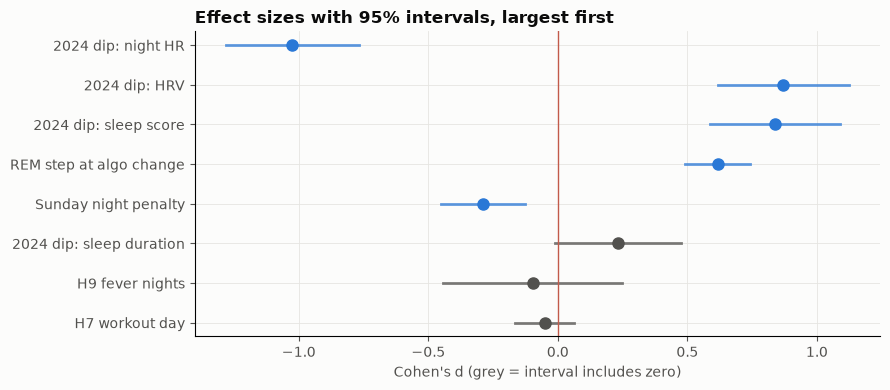

In [11]:
has_workout = pd.Series(sp.index.date).isin(set(wk.day.dt.date)).values

def entry(label, a, b):
    res = cohens_d(a, b)
    return (label, res["d"], res["ci"])

forest = [
    entry("2024 dip: night HR", base.lowest_hr.dropna(), dip.lowest_hr.dropna()),
    entry("2024 dip: HRV", base.avg_hrv.dropna(), dip.avg_hrv.dropna()),
    entry("2024 dip: sleep score", base.sleep_score.dropna(), dip.sleep_score.dropna()),
    ("REM step at algo change", cd_step["d"], cd_step["ci"]),
    entry("2024 dip: sleep duration", base.sleep_hours.dropna(), dip.sleep_hours.dropna()),
    entry("Sunday night penalty", score[score.index.dayofweek == 0],
          score[score.index.dayofweek != 0]),
    entry("H7 workout day", sp.rem_pct[has_workout].dropna(),
          sp.rem_pct[~has_workout].dropna()),
    entry("H9 fever nights", d3[d3.temp_deviation > 0.5].rem_pct.dropna(),
          d3[d3.temp_deviation <= 0.5].rem_pct.dropna()),
]
forest = sorted(forest, key=lambda t: abs(t[1]), reverse=True)

fig, ax = plt.subplots(figsize=(9, 4))
for i, (label, d, ci) in enumerate(forest):
    crosses = ci[0] <= 0 <= ci[1]
    c = INK2 if crosses else BLUE
    ax.plot([ci[0], ci[1]], [i, i], color=c, linewidth=2, alpha=0.75)
    ax.plot([d], [i], "o", color=c, markersize=8)
ax.axvline(0, color=RED, linewidth=1)
ax.set_yticks(range(len(forest)))
ax.set_yticklabels([f[0] for f in forest])
ax.invert_yaxis()
ax.set_xlabel("Cohen's d (grey = interval includes zero)")
ax.set_title("Effect sizes with 95% intervals, largest first",
             loc="left", fontweight="bold", color=INK)
plt.tight_layout(); plt.show()

## What changed

| Claim | Originally | After robustness testing |
|---|---|---|
| 2024 dip was physiological | p < 1e-10 | **Holds.** d = 0.84 to 1.02, p around 1e-4 on effective n |
| Sunday night is worst | CI 1.4 to 5.7 pts | **Holds.** Permutation p = 0.0007, CI 1.3 to 5.5 pts |
| Duration drives REM | r = 0.80 | **Holds, stronger.** r = 0.82 within week |
| Duration drives sleep score | r = 0.74 | **Holds, stronger.** r = 0.77 within week |
| Sleep score tracks readiness | r = 0.67 | **Holds, stronger.** r = 0.72 within week |
| Bedtime does not affect REM share | null | **Holds.** Strong null, detectable r = 0.08 |
| Stress and training do not affect REM | clean nulls | **Holds, and stated properly** as evidence of absence |
| HRV does not affect REM share | clean null | **Amended.** r = -0.066, p = 0.019: detectable, negligible, wrong sign |
| Illness does not affect REM | clean null | **Withdrawn.** n = 33 detects only r = 0.47 |
| Previous-day activity barely matters | r = 0.09 | **Confirmed as zero.** r = 0.01 within week |
| Weekend REM is higher | p = 0.011 | **Downgraded.** Permutation p = 0.15, CI includes zero |
| REM declining 1.1 pp/year | p = 3e-8 | **Withdrawn.** Bootstrap CI straddles zero; a step change at the algorithm update fits better |

Nine claims hold or get stronger, one is amended, two are withdrawn. Both
withdrawals rested on long-run change in a persistent signal, which is exactly
where the independence assumption does the most damage. Nothing that rests on
a same-day or within-week mechanism moved at all.

**What this changes about the headline.** Nothing. Bedtime timing beating
consistency, and duration being the only real lever on REM, are both same-day
within-week effects measured across more than a thousand nights. Those are the
claims this dataset is built to support. The claims it could not support were
the ones about slow change over years, where four years of one person's data
carries far less information than the night count implies.